In [1]:
import pandas as pd
df = pd.read_csv("../data/titanic_data.csv")

* Bar Graph

* Pie Chart

* Histogram

* Kde graph

* Line Graph

* Scatter Plot

* Bubble Chart
 
* Heatmap

* Box Plot

* Violien Chart

* Pair Plot

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 1. Bar Chart

[Text(0, 3, '549'), Text(0, 3, '342')]

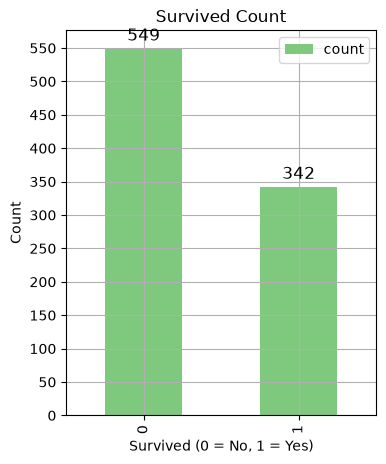

In [8]:
ax = df.Survived.value_counts().plot(
    kind= "bar",
    title= "Survived Count",
    figsize= (4, 5),
    legend= True,
    xlabel= "Survived (0 = No, 1 = Yes)",
    ylabel= "Count",
    grid= True,
    yticks= range(0, 551, 50),
    cmap= "Accent",
    # color= ["#FF0000", "#00FF00"] for defining custom colors
)
# add numbers above each bar
ax.bar_label(ax.containers[0], label_type= "edge", fontsize= 12, color= "black", padding= 3)

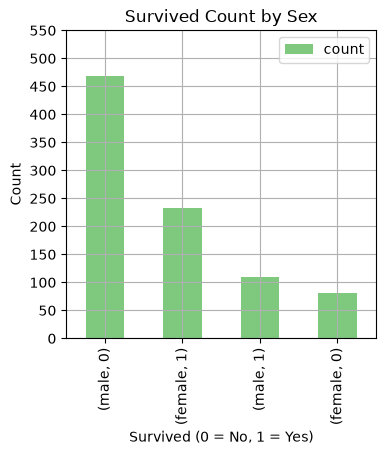

In [10]:
ax = df.value_counts(subset= ["Sex", "Survived"]).plot(
    kind= "bar",
    title= "Survived Count by Sex",
    figsize= (4, 4),
    legend= True,
    xlabel= "Survived (0 = No, 1 = Yes)",
    ylabel= "Count",
    grid= True,
    yticks= range(0, 551, 50),
    cmap= "Accent",
)

In [11]:
cross_tab = pd.crosstab(df.Survived, df.Pclass)
cross_tab

Pclass,1,2,3
Survived,,,
0,80,97,372
1,136,87,119


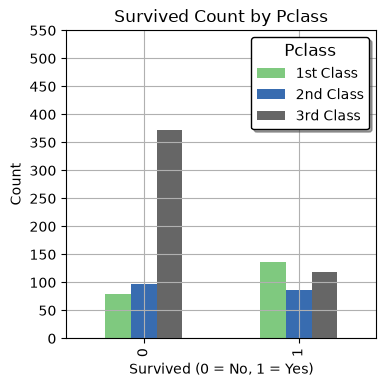

In [ ]:
ax = cross_tab.plot(
    kind= "bar",
    title= "Survived Count by Pclass",
    figsize= (4, 4),
    legend= True,
    xlabel= "Survived (0 = No, 1 = Yes)",
    ylabel= "Count",
    grid= True,
    yticks= range(0, 551, 50),
    cmap= "Accent",
)
ax.legend(
    title= "Pclass",
    title_fontsize= 12, # title font size
    fontsize= 10, # font size of the legend labels
    loc= "upper right", # location of the legend
    borderaxespad= 0.5, # distance between the legend and the axes
    shadow= True, # add shadow to the legend
    facecolor= "white", # background color of the legend
    edgecolor= "black", # border color of the legend
    framealpha= 1, # transparency of the legend
    labels= ["1st Class", "2nd Class", "3rd Class"]
    )

### 2.Pie Chart

In [14]:
group_by_embarked = df.groupby(by = "Embarked")
group_by_embarked.count()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin
Embarked,,,,,,,,,,,
C,168,168,168,168,168,130,168,168,168,168,69
Q,77,77,77,77,77,28,77,77,77,77,4
S,644,644,644,644,644,554,644,644,644,644,129


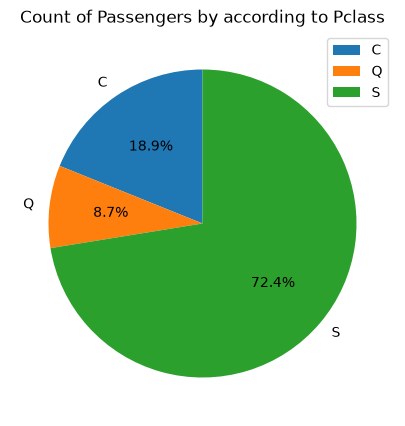

In [16]:
ax = group_by_embarked.count().plot(
    kind= "pie",
    y= "Survived", # y is the column to plot
    title= "Count of Passengers by according to Pclass",
    autopct= "%1.1f%%", # show percentage on the pie chart
    startangle= 90, # start angle of the pie chart
    figsize= (5, 5),
)

In [18]:
cross_tab = pd.crosstab(df.Sex, df.Survived)
cross_tab

Survived,0,1
Sex,,
female,81,233
male,468,109


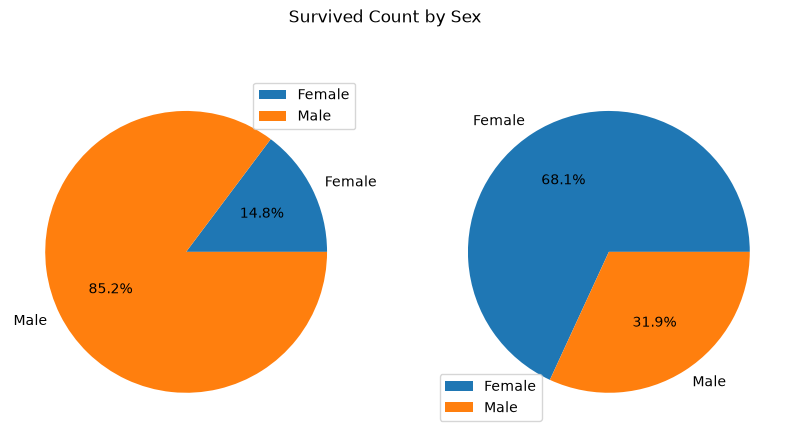

In [22]:
ax = cross_tab.plot(
    kind= "pie",
    subplots= True, # create a separate pie chart for each column
    title= "Survived Count by Sex",
    autopct= "%1.1f%%", # show percentage on the pie chart,
    figsize= (10, 5),
    labels= ["Female", "Male"],
)

### 3.Histogram

In [23]:
df.Age

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

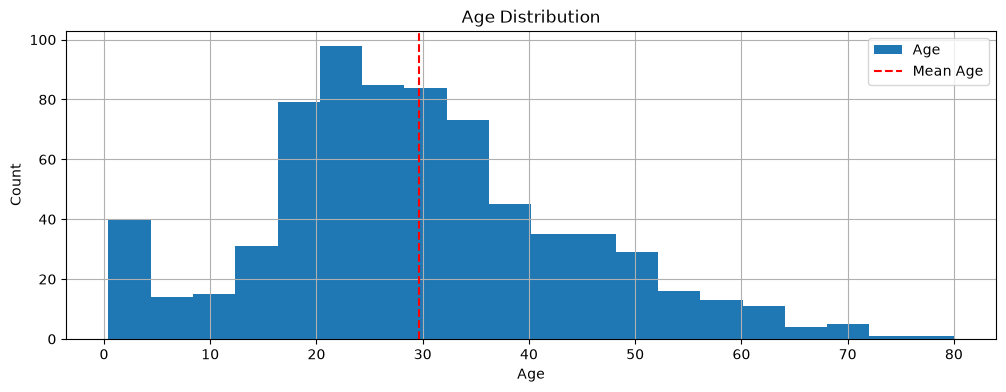

In [31]:
ax = df.Age.plot(
    kind= "hist",
    bins= 20, # bins is the number of intervals to divide the data into
    title= "Age Distribution",
    grid= True,
    figsize= (12, 4),
)
ax.set_xlabel("Age")
ax.set_ylabel("Count")
df.Age.mean()
ax.axvline(df.Age.mean(), color= "red", linestyle= "--", label= "Mean Age")
ax.legend()

### 4.Kde graph

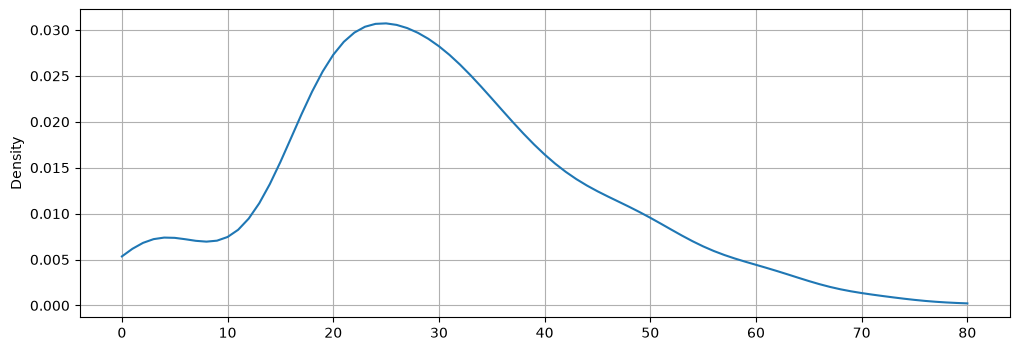

In [32]:
ax = df.Age.plot(
    kind= "kde",
    grid= True, 
    ind = range(0, 81),
    figsize= (12, 4),
)

In [33]:
df[["Age", "Survived"]]

,Age,Survived
0,22.0,0
1,38.0,1
2,26.0,1
3,35.0,1
4,35.0,0
...,...,...
886,27.0,0
887,19.0,1
888,NaN,0
889,26.0,1


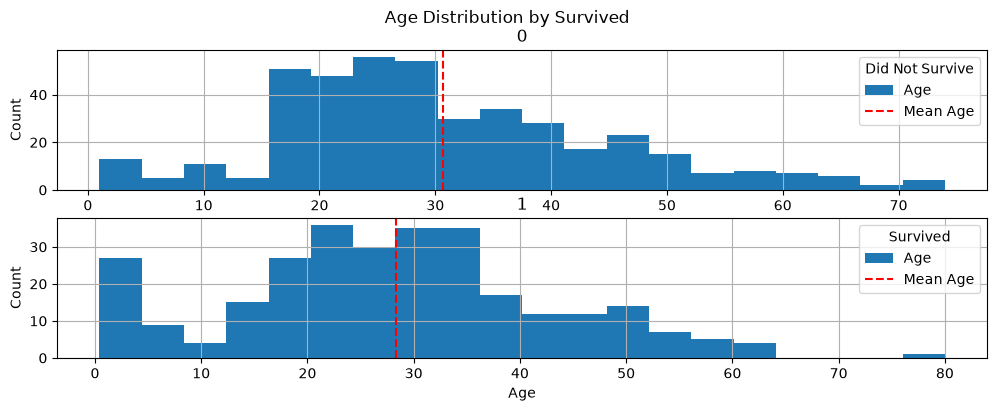

In [37]:
ax = df[["Age", "Survived"]].plot(
    kind= "hist",
    by = "Survived", # group by Survived column,
    bins= 20, # bins is the number of intervals to divide the data into
    title= "Age Distribution by Survived",
    grid= True,
    figsize= (12, 4),
)
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Count")
ax[1].set_xlabel("Age")
ax[1].set_ylabel("Count")
ax[0].axvline(df[df.Survived == 0].Age.mean(), color= "red", linestyle= "--", label= "Mean Age")
ax[1].axvline(df[df.Survived == 1].Age.mean(), color= "red", linestyle= "--", label= "Mean Age")
ax[0].legend(title= "Did Not Survive", loc= "upper right")
ax[1].legend(title= "Survived", loc= "upper right")

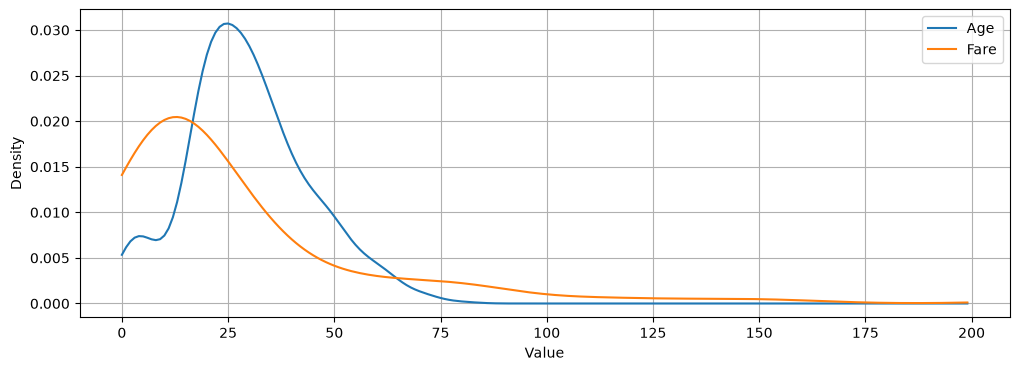

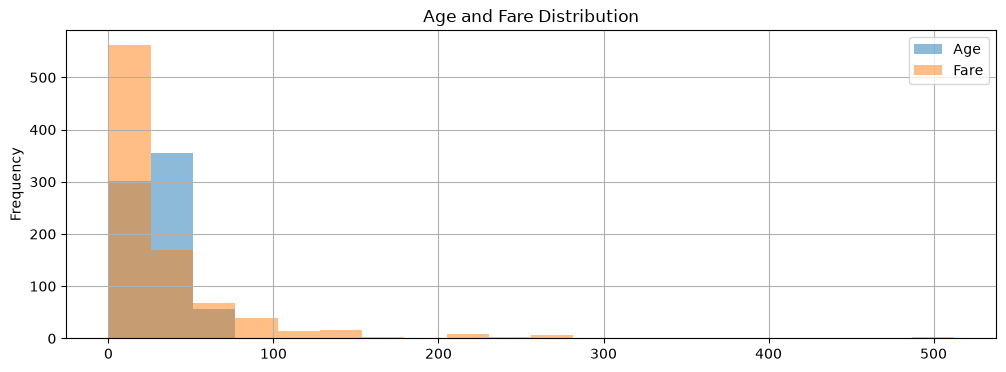

In [38]:
ax = df[["Age", "Fare"]].plot(
    kind= "kde",
    grid= True,
    figsize= (12, 4),
    ind= range(0, 200)
)
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax = df[["Age", "Fare"]].plot(
    kind= "hist",
    bins= 20, # bins is the number of intervals to divide the data into
    title= "Age and Fare Distribution",
    grid= True,
    figsize= (12, 4),
    alpha= 0.5, # transparency of the bars
)

### 5.Line Graph

In [39]:
df.Fare.loc[:100]

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
96     34.6542
97     63.3583
98     23.0000
99     26.0000
100     7.8958
Name: Fare, Length: 101, dtype: float64

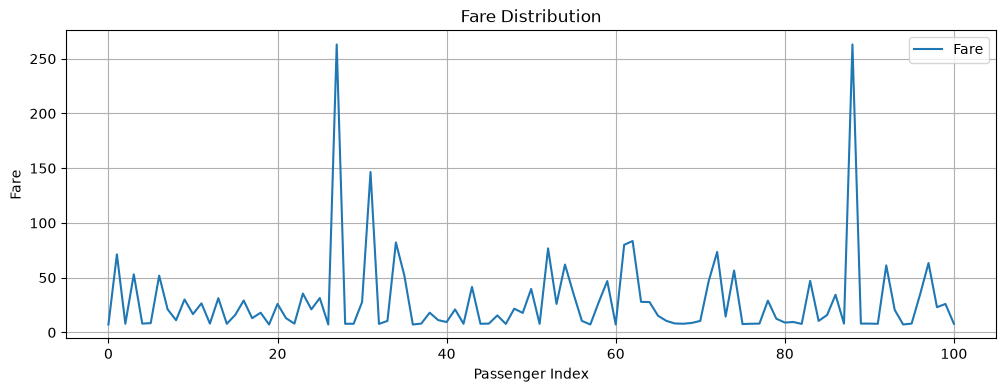

In [ ]:
ax = df.Fare.loc[:100].plot(
    kind= "line",
    title= "Fare Distribution",
    grid= True,
    figsize= (12, 4),
    xlabel= "Passenger Index",
    ylabel= "Fare",
    legend=True
)

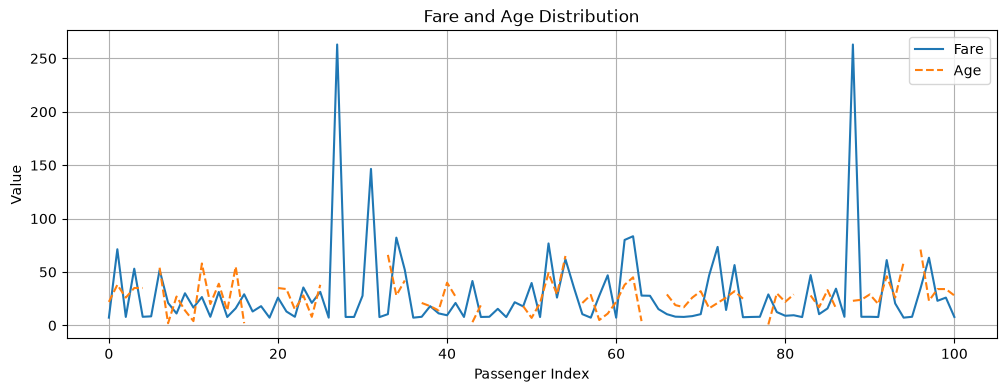

In [46]:
ax = df[["Fare", "Age"]].loc[:100].plot(
    kind= "line",
    title= "Fare and Age Distribution",
    grid= True,
    figsize= (12, 4),
    xlabel= "Passenger Index",
    ylabel= "Value",
    legend=True,
    style= ["-", "--"],
)


### 6.Scatter plot

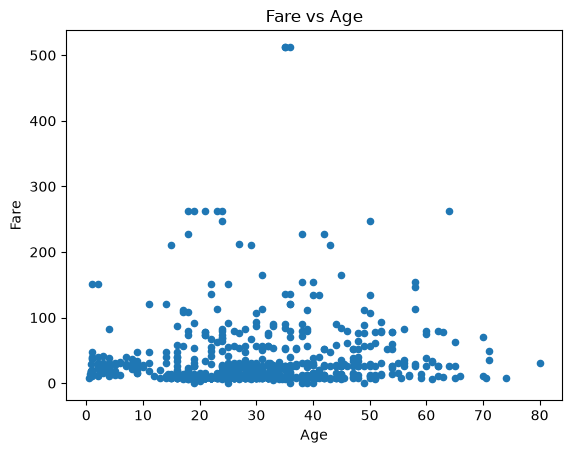

In [51]:
ax = df.plot(
    kind= "scatter",
    x= "Age", # x-axis is Age
    y= "Fare",# y-axis is Fare
    title= "Fare vs Age",
    legend=True,
)

In [52]:
df["SibSp"] = df.SibSp * 10

<Axes: xlabel='Age', ylabel='Fare'>

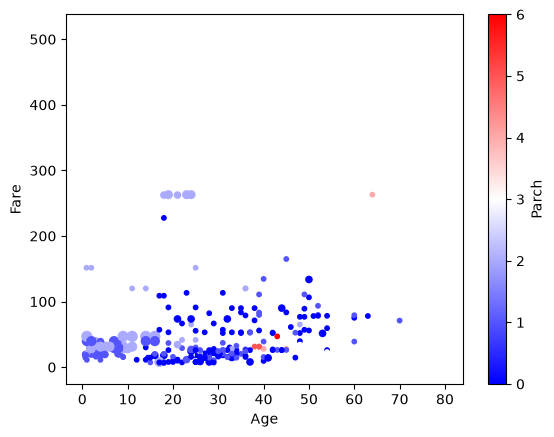

In [58]:
df.plot(
    kind = "scatter",
    x = "Age", 
    y = "Fare",
    s = "SibSp", # size of the points is determined by the SibSp column
    c = "Parch", # color of the points is determined by the Parch column
    colormap = "bwr",
)